LINEAR REGRESSION

   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...
   word_count  text_length
0          28          141
1          23          138
2          28          148
3          32          164
4          27          140
MAE: 10.978262289861213
R2 Score: 0.8373239498788766


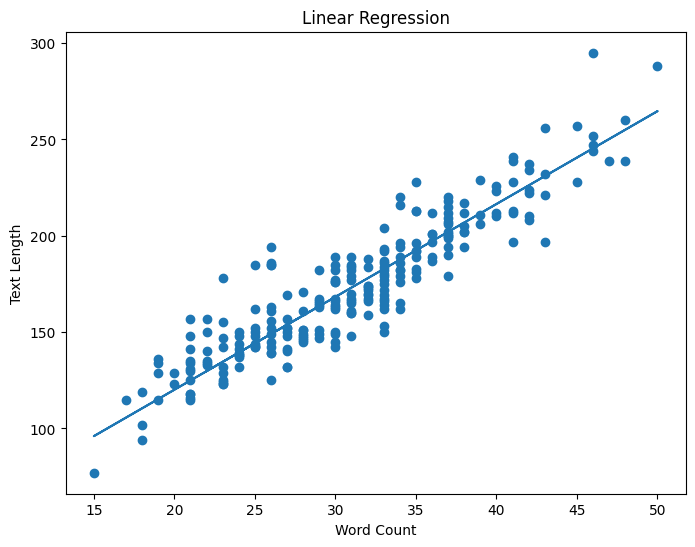

Predicted Text Length: 71.88046932686541


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv('/content/Symptom2Disease.csv')

# Display dataset
print(df.head())

# Remove null values
df = df.dropna()

# Create text length column
df['text_length'] = df['text'].apply(len)

# Create word count column
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

# Dataset for linear regression
linear_dataset = df[['word_count', 'text_length']]

# Display dataset used
print(linear_dataset.head())

# Features
X = linear_dataset[['word_count']]

# Target
y = linear_dataset['text_length']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict values
predictions = model.predict(X_test)

# Display evaluation results
print("MAE:", mean_absolute_error(y_test, predictions))

print("R2 Score:", r2_score(y_test, predictions))

# Plot graph
plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test)

plt.plot(X_test, predictions)

plt.xlabel("Word Count")

plt.ylabel("Text Length")

plt.title("Linear Regression")

plt.show()

# Sample prediction
sample_data = pd.DataFrame({
    'word_count': [10]
})

sample_prediction = model.predict(sample_data)

# Display prediction
print("Predicted Text Length:",
      sample_prediction[0])

MULTI LINEAR REGRESSION

   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...
   word_count  label_encoded  text_length
0          28             15          141
1          23             15          138
2          28             15          148
3          32             15          164
4          27             15          140
MAE: 10.960520279577581
R2 Score: 0.8378204965154197


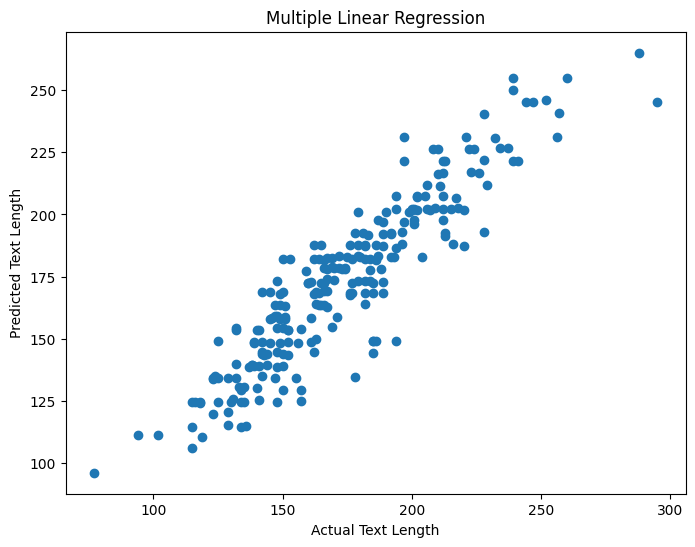

Predicted Text Length: 72.71921081072438


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('/content/Symptom2Disease.csv')

# Display dataset
print(df.head())

# Remove null values
df = df.dropna()

# Create text length column
df['text_length'] = df['text'].apply(len)

# Create word count column
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

# Encode labels
encoder = LabelEncoder()

df['label_encoded'] = encoder.fit_transform(
    df['label']
)

# Dataset for multiple linear regression
multi_dataset = df[['word_count',
                    'label_encoded',
                    'text_length']]

# Display dataset used
print(multi_dataset.head())

# Features
X = multi_dataset[['word_count',
                   'label_encoded']]

# Target
y = multi_dataset['text_length']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict values
predictions = model.predict(X_test)

# Display evaluation results
print("MAE:", mean_absolute_error(y_test, predictions))

print("R2 Score:", r2_score(y_test, predictions))

# Plot graph
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Text Length")

plt.ylabel("Predicted Text Length")

plt.title("Multiple Linear Regression")

plt.show()

# Sample prediction
sample_data = pd.DataFrame({
    'word_count': [10],
    'label_encoded': [5]
})

sample_prediction = model.predict(sample_data)

# Display prediction
print("Predicted Text Length:",
      sample_prediction[0])